# NBA Betting Analytics & Statistics: Can the Market Be Beat?

**Author: Nils Osterloff**
Course: 2586 (2026/P4) Python Programming for Business Intelligence, Hki & Vaasa
Date: May 10th 2026

---

## How to Use My Notebook

### Requirements:
- Python 3.9+
- Libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `anthropic`, `python-dotenv`
- Install with: `pip install pandas numpy matplotlib seaborn scipy anthropic python-dotenv`

### The Setup:
1. Place `nba_2008-2025.csv` in the same directory as this notebook (download from [Kaggle](https://www.kaggle.com/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024))
2. Create a `.env` file in the same directory with your Anthropic API key:
   ```
   ANTHROPIC_API_KEY=your_key_here
   ```
3. Run all cells from top to bottom (`Kernel → Restart & Run All`)

### Structure:
| Section | Description |
|---|---|
| 1. Data Pipeline Overview | Visual summary of the notebook flow |
| 2. Data Loading | Load CSV + export raw snapshot |
| 3. Data Cleaning | Handle missing values, derive features |
| 4. Analysis | Visual + quantitative exploration |
| 5. API – LLM Insights | Claude interprets key findings |
| 6. Export | Save cleaned data and results |
| 7. Conclusion | Summary of findings |
| 8. AI Use Statement | Disclosure of AI usage |

## 1. Introduction

### Background
Sports betting markets are often assumed to be efficient, i.e., the point spread set by bookmakers should be an unbiased predictor of the actual game margin. If markets are efficient, no systematic strategy should yield consistent profits.

### Research Goals
My final project investigates three questions using NBA game data from 2008–2025:

1. **Home court advantage:** How large is it, and has it changed over time?
2. **Betting market efficiency:** Does the spread accurately predict outcomes? Are there team-level biases?
3. **Scoring trends:** How have total points and game pace evolved over the shot-clock era?

### Data Source
- **Primary:** [NBA Betting Data (Kaggle)](https://www.kaggle.com/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024) 23,118 games with betting lines from 2008–2025
- **API:** Anthropic Claude API, which is used to generate plain-language interpretations of statistical findings

## 2. Data Pipeline Overview

The image below describes the full data pipeline in this notebook.

![Data Pipeline](pipeline.png)

> **Note:** The pipeline image (`pipeline.png`) must be in the same directory. It illustrates: Raw CSV → Load & Inspect → Clean & Feature Engineer → Analyze (Visual + Statistical) → LLM Interpretation (Claude API) → Export Results.

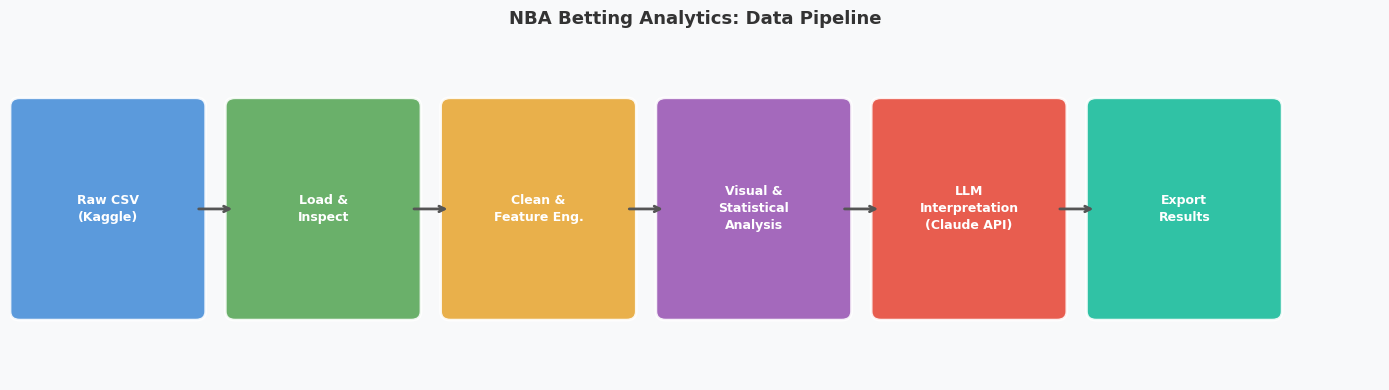

Pipeline diagram saved as pipeline.png


In [1]:
# Generate the pipeline diagram programmatically so it's self-contained
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

steps = [
    (1.0,  'Raw CSV\n(Kaggle)',          '#4A90D9'),
    (3.2,  'Load &\nInspect',            '#5BA85A'),
    (5.4,  'Clean &\nFeature Eng.',      '#E8A838'),
    (7.6,  'Visual &\nStatistical\nAnalysis', '#9B59B6'),
    (9.8,  'LLM\nInterpretation\n(Claude API)', '#E74C3C'),
    (12.0, 'Export\nResults',            '#1ABC9C'),
]

for x, label, color in steps:
    box = FancyBboxPatch((x - 0.9, 0.8), 1.8, 2.4,
                         boxstyle='round,pad=0.1',
                         facecolor=color, edgecolor='white',
                         linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, 2.0, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            linespacing=1.4)

for i in range(len(steps) - 1):
    x_start = steps[i][0] + 0.9
    x_end   = steps[i+1][0] - 0.9
    ax.annotate('', xy=(x_end, 2.0), xytext=(x_start, 2.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

ax.set_title('NBA Betting Analytics: Data Pipeline', fontsize=13,
             fontweight='bold', pad=10, color='#333')
plt.tight_layout()
plt.savefig('pipeline.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Pipeline diagram saved as pipeline.png')

## 3. Data Loading

In [21]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv
import anthropic

warnings.filterwarnings("ignore")

# Load API key from .env file
load_dotenv(r'C:\Users\nisse\OneDrive\Dokumente\.env')

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print("Libraries loaded successfully.")
print(f"API key loaded: {bool(os.getenv(chr(65)+chr(78)+chr(84)+chr(72)+chr(82)+chr(79)+chr(80)+chr(73)+chr(67)+chr(95)+chr(65)+chr(80)+chr(73)+chr(95)+chr(75)+chr(69)+chr(89)))}")


Libraries loaded successfully.
API key loaded: True


In [23]:
# Load the raw NBA betting dataset from Kaggle CSV
CSV_PATH = 'nba_2008-2025.csv'

df_raw = pd.read_csv(CSV_PATH)
print(f'Loaded dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Seasons covered: {sorted(df_raw["season"].unique())}')
display(df_raw.head(3))

Loaded dataset: 23,118 rows × 27 columns
Seasons covered: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,...,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
0,2008,2007-10-30,True,False,por,sa,97,106,26,23,...,0,home,13.0,189.5,900.0,-1400.0,5.0,95.0,0.0,1
1,2008,2007-10-30,True,False,utah,gs,117,96,28,34,...,0,home,1.0,212.0,100.0,-120.0,3.0,105.5,0.0,1
2,2008,2007-10-30,True,False,hou,lal,95,93,16,27,...,0,away,5.0,199.0,-230.0,190.0,3.0,99.0,0.0,0


In [24]:
# Inspect missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].rename('missing_count').to_frame()
missing['pct'] = (missing['missing_count'] / len(df_raw) * 100).round(2)
print('Columns with missing values:')
display(missing)

Columns with missing values:


,missing_count,pct
spread,3,0.01
moneyline_away,3298,14.27
moneyline_home,3298,14.27
h2_spread,3296,14.26
h2_total,3301,14.28
id_spread,3,0.01


In [25]:
# Export raw data snapshot so reviewers can run the notebook without Kaggle
RAW_EXPORT_PATH = 'nba_raw_snapshot.csv'
df_raw.to_csv(RAW_EXPORT_PATH, index=False)
print(f'Raw snapshot saved → {RAW_EXPORT_PATH}')


# ALTERNATIVE: If you don't have the original CSV, load the snapshot instead
# df_raw = pd.read_csv('nba_raw_snapshot.csv')

Raw snapshot saved → nba_raw_snapshot.csv


## 4. Data Cleaning & Feature Engineering

In [26]:
# Work on a copy; keep only regular season games for main analysis
df = df_raw.copy()

# Parse date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Separate regular season and playoffs
df_reg    = df[df['regular'] == 1].copy()
df_playoff = df[df['regular'] == 0].copy()
print(f'Regular season games : {len(df_reg):,}')
print(f'Playoff games        : {len(df_playoff):,}')

Regular season games : 21,578
Playoff games        : 1,540


In [27]:
# Derived features
df_reg['point_diff']   = df_reg['score_home'] - df_reg['score_away']  # positive = home win margin
df_reg['home_win']     = (df_reg['point_diff'] > 0).astype(int)
df_reg['total_points'] = df_reg['score_home'] + df_reg['score_away']

# Spread cover: home team covers if point_diff > spread (spread is positive when home is favored)
# A spread of 6 means home is favored by 6 — home covers if they win by more than 6
df_reg['home_covers']  = (df_reg['point_diff'] > df_reg['spread']).astype(int)

# Over/Under result
df_reg['went_over']    = (df_reg['total_points'] > df_reg['total']).astype(int)

# Drop rows without a spread (only 3 rows)
df_reg = df_reg.dropna(subset=['spread'])

print(f'Clean regular-season dataset: {df_reg.shape[0]:,} rows × {df_reg.shape[1]} columns')
display(df_reg[['season','date','home','away','score_home','score_away',
                'point_diff','home_win','spread','home_covers',
                'total','total_points','went_over']].head(5))

Clean regular-season dataset: 21,575 rows × 32 columns


,season,date,home,away,score_home,score_away,point_diff,home_win,spread,home_covers,total,total_points,went_over
0,2008,2007-10-30,sa,por,106,97,9,1,13.0,0,189.5,203,1
1,2008,2007-10-30,gs,utah,96,117,-21,0,1.0,0,212.0,213,1
2,2008,2007-10-30,lal,hou,93,95,-2,0,5.0,0,199.0,188,0
3,2008,2007-10-31,tor,phi,106,97,9,1,6.5,1,191.0,203,1
4,2008,2007-10-31,ind,wsh,119,110,9,1,1.5,1,203.5,229,1


## 5. Analysis

### 5.1 Home Court Advantage

In [28]:
# Overall home win rate and average margin
home_win_rate  = df_reg['home_win'].mean()
avg_home_margin = df_reg['point_diff'].mean()

# One-sample t-test: is the average point differential > 0?
t_stat, p_val = stats.ttest_1samp(df_reg['point_diff'], popmean=0)

print(f'Overall home win rate : {home_win_rate:.1%}')
print(f'Average home margin   : {avg_home_margin:+.2f} points')
print(f't-test (H₀: margin=0) : t = {t_stat:.2f},  p = {p_val:.2e}')

Overall home win rate : 57.9%
Average home margin   : +2.53 points
t-test (H₀: margin=0) : t = 26.63,  p = 1.02e-153


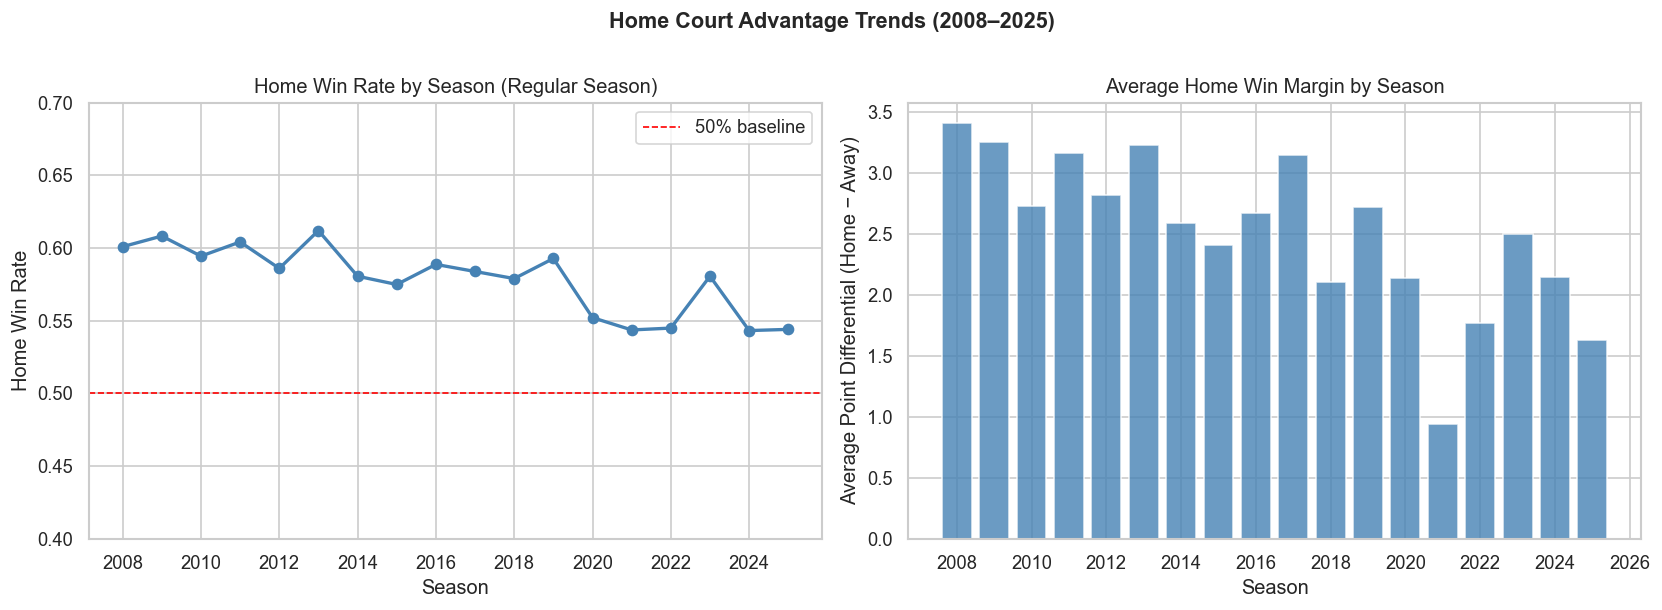

In [29]:
# Home win rate and average margin per season
season_stats = df_reg.groupby('season').agg(
    home_win_rate  = ('home_win',    'mean'),
    avg_margin     = ('point_diff',  'mean'),
    games          = ('home_win',    'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Home win rate over time
axes[0].plot(season_stats['season'], season_stats['home_win_rate'],
             marker='o', linewidth=2, color='steelblue')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
axes[0].set_title('Home Win Rate by Season (Regular Season)')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Home Win Rate')
axes[0].set_ylim(0.40, 0.70)
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))

# Plot 2: Average home margin over time
axes[1].bar(season_stats['season'], season_stats['avg_margin'],
            color='steelblue', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Home Win Margin by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Point Differential (Home − Away)')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.suptitle('Home Court Advantage Trends (2008–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_home_court.png', bbox_inches='tight')
plt.show()

### 5.2 Betting Market Efficiency

In [30]:
# Regression: does the spread predict the actual point differential?
# If market-efficient: intercept ≈ 0, slope ≈ 1
slope, intercept, r_val, p_val, se = stats.linregress(
    df_reg['spread'], df_reg['point_diff']
)

print('OLS: point_diff ~ spread')
print(f'  Intercept : {intercept:.4f}')
print(f'  Slope     : {slope:.4f}  (efficient market → 1.0)')
print(f'  R²        : {r_val**2:.4f}')
print(f'  p-value   : {p_val:.2e}')



# Home cover rate overall
cover_rate = df_reg['home_covers'].mean()
binom_pval = stats.binomtest(df_reg['home_covers'].sum(), len(df_reg), 0.5).pvalue
print(f'\nHome team covers spread: {cover_rate:.1%}  (p = {binom_pval:.4f})')

OLS: point_diff ~ spread
  Intercept : -2.5929
  Slope     : 0.8283  (efficient market → 1.0)
  R²        : 0.0486
  p-value   : 9.02e-236

Home team covers spread: 40.6%  (p = 0.0000)


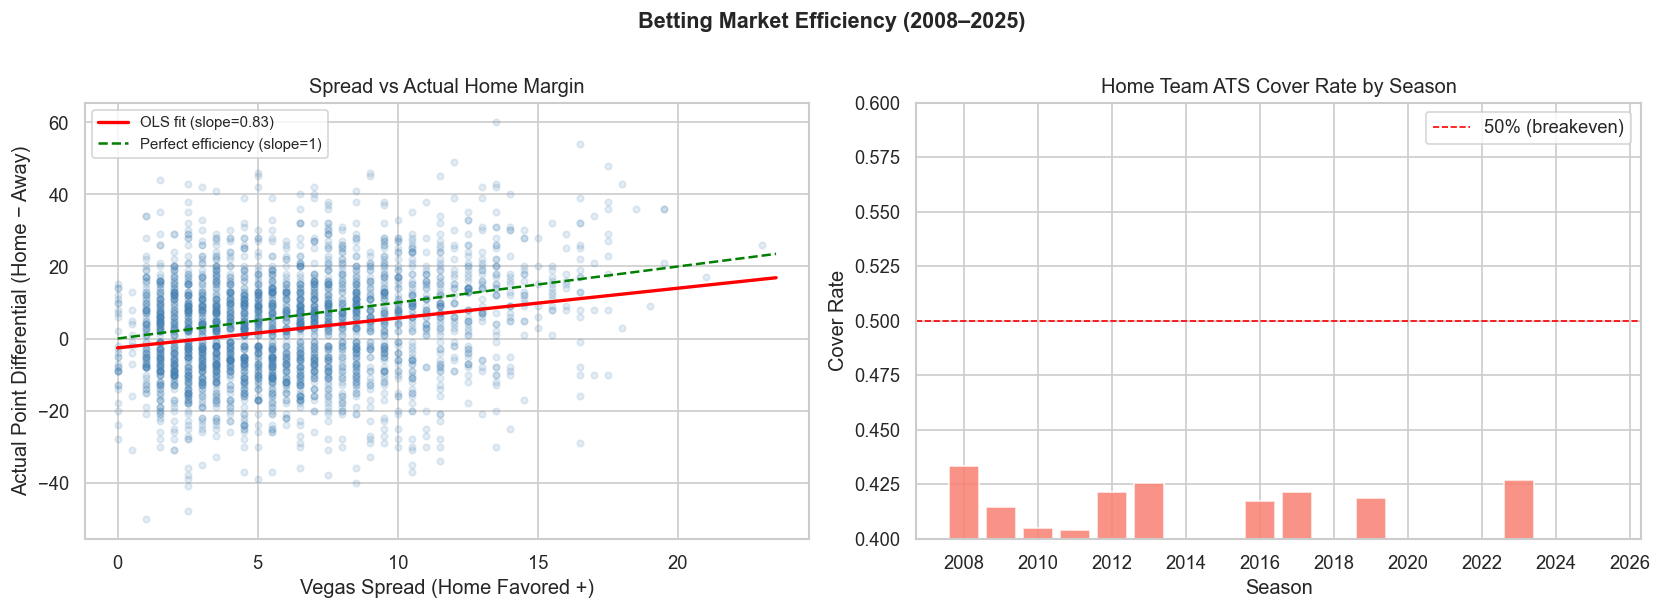

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Spread vs actual margin scatter
sample = df_reg.sample(3000, random_state=42)  # subsample for readability
axes[0].scatter(sample['spread'], sample['point_diff'],
                alpha=0.15, s=15, color='steelblue')
x_line = np.linspace(df_reg['spread'].min(), df_reg['spread'].max(), 100)
axes[0].plot(x_line, intercept + slope * x_line,
             color='red', linewidth=2, label=f'OLS fit (slope={slope:.2f})')
axes[0].plot(x_line, x_line, color='green', linestyle='--',
             linewidth=1.5, label='Perfect efficiency (slope=1)')
axes[0].set_title('Spread vs Actual Home Margin')
axes[0].set_xlabel('Vegas Spread (Home Favored +)')
axes[0].set_ylabel('Actual Point Differential (Home − Away)')
axes[0].legend(fontsize=9)

# Plot 2: Home cover rate by season
cover_by_season = df_reg.groupby('season')['home_covers'].mean().reset_index()
axes[1].bar(cover_by_season['season'], cover_by_season['home_covers'],
            color='salmon', alpha=0.85)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% (breakeven)')
axes[1].set_title('Home Team ATS Cover Rate by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Cover Rate')
axes[1].set_ylim(0.40, 0.60)
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.suptitle('Betting Market Efficiency (2008–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_betting.png', bbox_inches='tight')
plt.show()

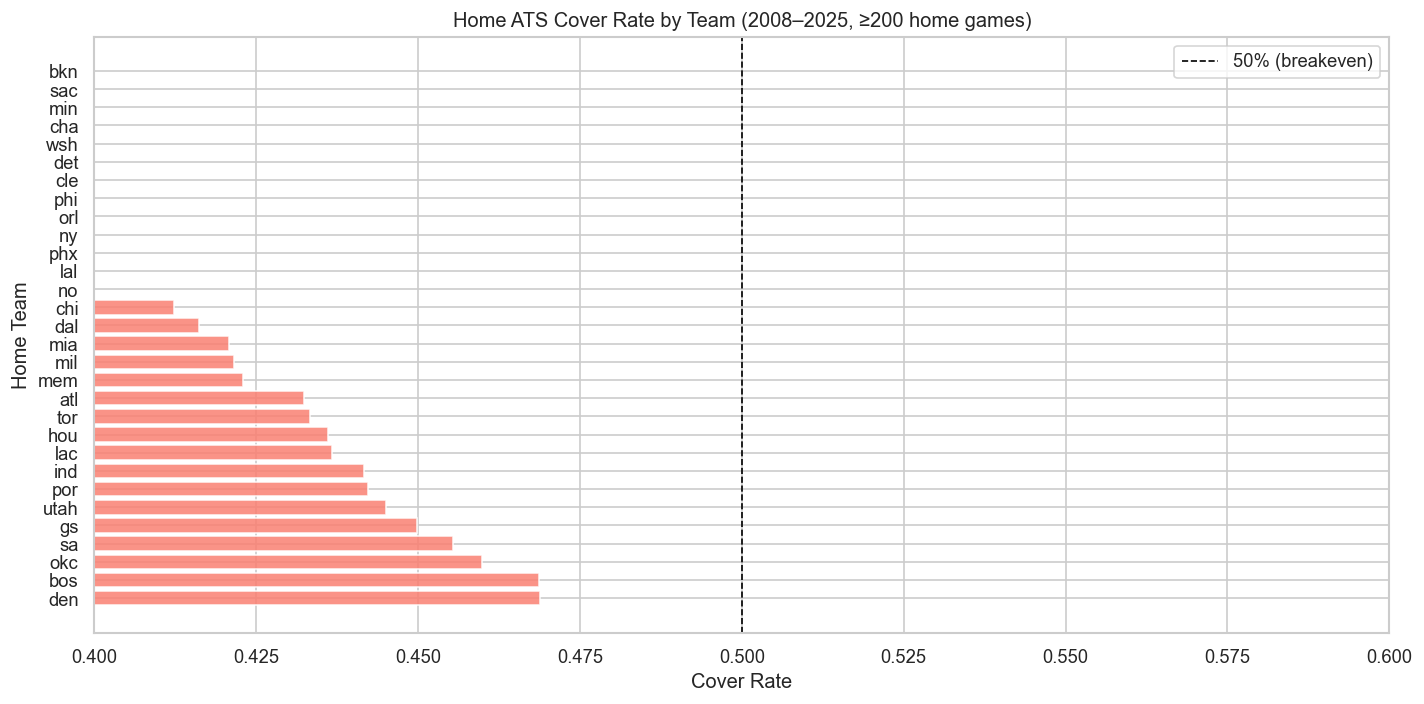

In [32]:
# Which teams cover the spread most (and least) often? (min 200 home games)
team_covers = df_reg.groupby('home').agg(
    cover_rate = ('home_covers', 'mean'),
    games      = ('home_covers', 'count')
).query('games >= 200').sort_values('cover_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue' if x > 0.5 else 'salmon' for x in team_covers['cover_rate']]
ax.barh(team_covers.index, team_covers['cover_rate'], color=colors, alpha=0.85)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% (breakeven)')
ax.set_title('Home ATS Cover Rate by Team (2008–2025, ≥200 home games)', fontsize=12)
ax.set_xlabel('Cover Rate')
ax.set_ylabel('Home Team')
ax.set_xlim(0.40, 0.60)
ax.legend()
plt.tight_layout()
plt.savefig('fig_team_covers.png', bbox_inches='tight')
plt.show()

### 5.3 Scoring Trends

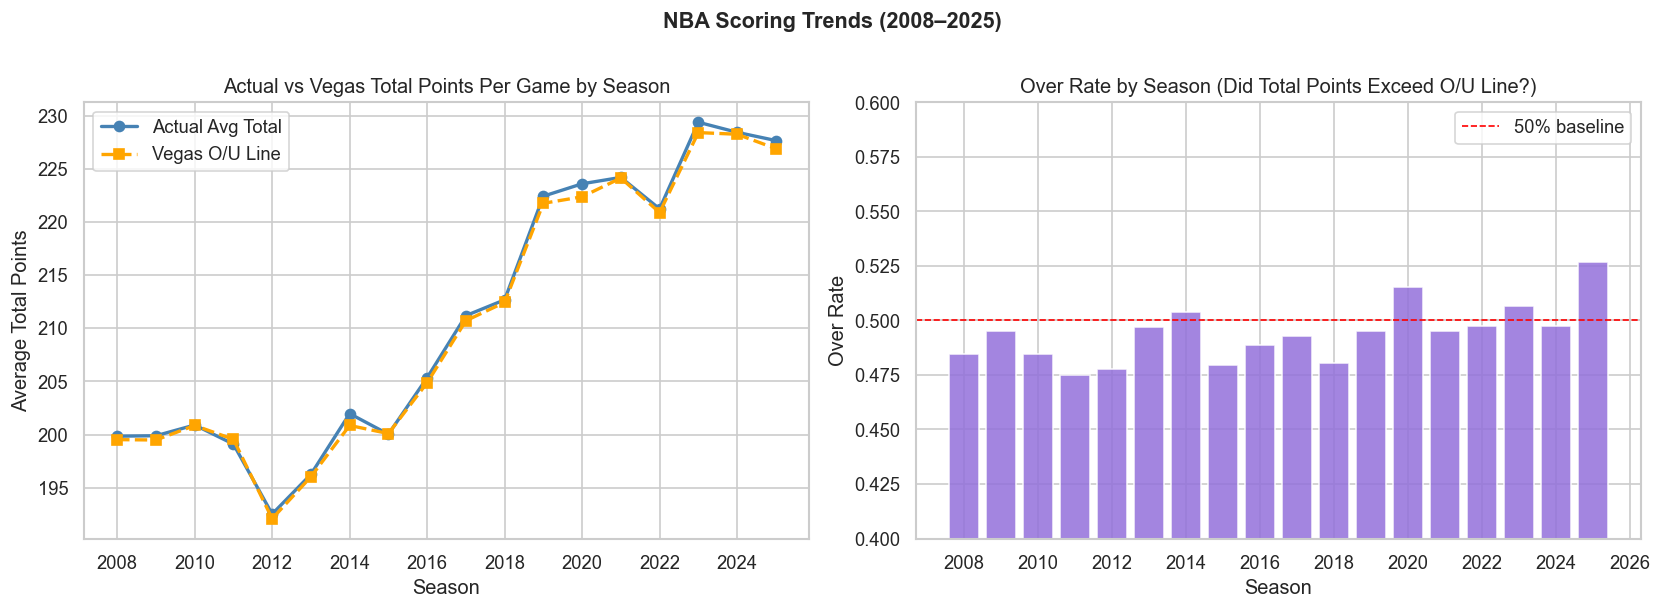

In [33]:
# Average total points and over/under line per season
scoring = df_reg.groupby('season').agg(
    avg_total_actual = ('total_points', 'mean'),
    avg_ou_line      = ('total',        'mean'),
    over_rate        = ('went_over',    'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual total vs O/U line over time
axes[0].plot(scoring['season'], scoring['avg_total_actual'],
             marker='o', label='Actual Avg Total', color='steelblue', linewidth=2)
axes[0].plot(scoring['season'], scoring['avg_ou_line'],
             marker='s', label='Vegas O/U Line', color='orange',
             linewidth=2, linestyle='--')
axes[0].set_title('Actual vs Vegas Total Points Per Game by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Total Points')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))

# Plot 2: Over rate per season
axes[1].bar(scoring['season'], scoring['over_rate'],
            color='mediumpurple', alpha=0.85)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
axes[1].set_title('Over Rate by Season (Did Total Points Exceed O/U Line?)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Over Rate')
axes[1].set_ylim(0.40, 0.60)
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.suptitle('NBA Scoring Trends (2008–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_scoring.png', bbox_inches='tight')
plt.show()

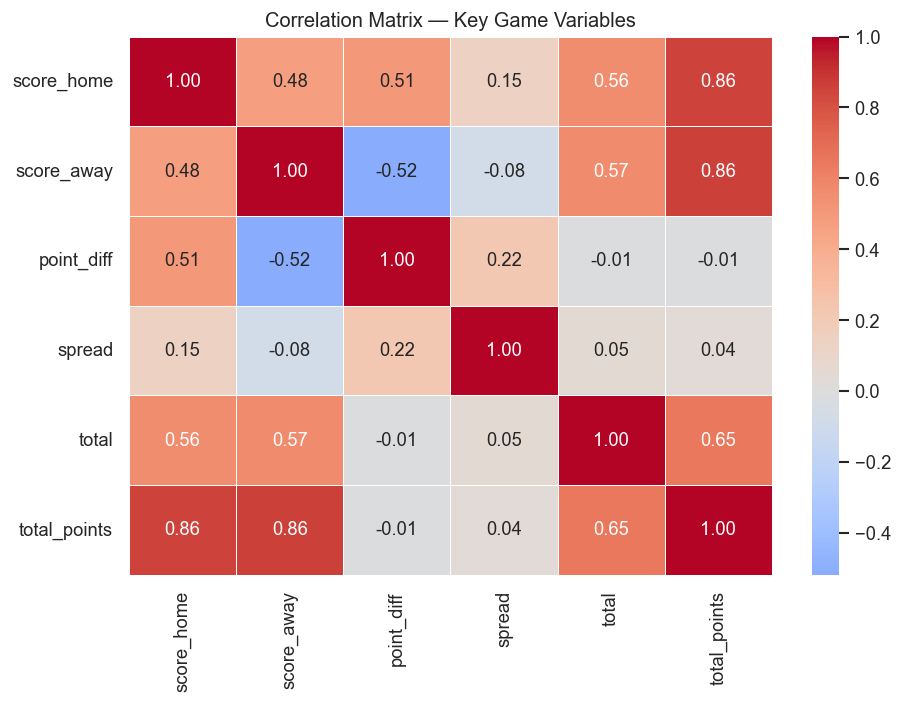

In [34]:
# Correlation matrix of key numeric variables
corr_cols = ['score_home', 'score_away', 'point_diff', 'spread', 'total', 'total_points']
corr_matrix = df_reg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Game Variables', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

## 6. API Component: LLM Interpretation via Claude

The following cells use the **Anthropic Claude API** to generate plain-language interpretations of the statistical findings computed above. The API receives a structured JSON summary of the results (no raw data is sent, only aggregated statistics), and returns a narrative insight for each research question.

This is a legitimate use of an LLM as an analytical tool: the model interprets numeric outputs, not generates data.

In [35]:
# Initialize the Anthropic client using the key loaded in the imports cell
api_key = os.getenv("ANTHROPIC_API_KEY")
if not api_key:
    raise ValueError("ANTHROPIC_API_KEY not found. Check your .env file.")

client = anthropic.Anthropic(api_key=api_key)
print("Anthropic client ready.")


Anthropic client ready.


In [36]:
# Build a structured summary of the statistical findings to send to Claude

# Best and worst ATS teams
top_cover    = team_covers.head(3).reset_index()[['home','cover_rate']].to_dict('records')
bottom_cover = team_covers.tail(3).reset_index()[['home','cover_rate']].to_dict('records')

# Scoring trend: first vs last 5 seasons
early_avg  = scoring[scoring['season'] <= 2012]['avg_total_actual'].mean()
recent_avg = scoring[scoring['season'] >= 2020]['avg_total_actual'].mean()

findings = {
    "home_court": {
        "overall_win_rate": round(home_win_rate, 4),
        "avg_margin_points": round(avg_home_margin, 2),
        "t_statistic": round(t_stat, 2),
        "p_value": round(p_val, 6),
        "covid_season_2020_win_rate": round(
            df_reg[df_reg['season']==2020]['home_win'].mean(), 4)
    },
    "betting_efficiency": {
        "ols_slope": round(slope, 4),
        "ols_intercept": round(intercept, 4),
        "r_squared": round(r_val**2, 4),
        "home_cover_rate_overall": round(cover_rate, 4),
        "top_covering_teams": top_cover,
        "worst_covering_teams": bottom_cover
    },
    "scoring_trends": {
        "avg_total_2008_2012": round(early_avg, 1),
        "avg_total_2020_2025": round(recent_avg, 1),
        "change_in_points": round(recent_avg - early_avg, 1),
        "overall_over_rate": round(df_reg['went_over'].mean(), 4)
    }
}

print('Statistical summary prepared:')
print(json.dumps(findings, indent=2))

Statistical summary prepared:
{
  "home_court": {
    "overall_win_rate": 0.5788,
    "avg_margin_points": 2.53,
    "t_statistic": 26.63,
    "p_value": 0.0,
    "covid_season_2020_win_rate": 0.552
  },
  "betting_efficiency": {
    "ols_slope": 0.8283,
    "ols_intercept": -2.5929,
    "r_squared": 0.0486,
    "home_cover_rate_overall": 0.4064,
    "top_covering_teams": [
      {
        "home": "den",
        "cover_rate": 0.46879334257975036
      },
      {
        "home": "bos",
        "cover_rate": 0.46870653685674546
      },
      {
        "home": "okc",
        "cover_rate": 0.4598337950138504
      }
    ],
    "worst_covering_teams": [
      {
        "home": "min",
        "cover_rate": 0.3254189944134078
      },
      {
        "home": "sac",
        "cover_rate": 0.3231197771587744
      },
      {
        "home": "bkn",
        "cover_rate": 0.31805555555555554
      }
    ]
  },
  "scoring_trends": {
    "avg_total_2008_2012": 198.4,
    "avg_total_2020_2025": 225.7

In [37]:
# Send findings to Claude API and get a narrative interpretation

prompt = f"""You are a sports analytics expert. Below is a JSON summary of statistical findings
from an analysis of {len(df_reg):,} NBA regular season games from 2008-2025.
Write a concise, insightful interpretation (3-4 paragraphs) of the findings for each of
the three topics: home court advantage, betting market efficiency, and scoring trends.
Be specific - reference the actual numbers. Conclude with one practical takeaway
for a bettor or analyst.

Findings:
{json.dumps(findings, indent=2)}
"""

response = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1000,
    messages=[{"role": "user", "content": prompt}]
)

llm_interpretation = response.content[0].text
print("=== Claude API Interpretation ===")
print(llm_interpretation)


=== Claude API Interpretation ===
# NBA Analytics: 2008-2025 Statistical Findings

## Home Court Advantage: A Robust and Persistent Edge

Home court advantage in the NBA is statistically significant and economically meaningful. Over 21,575 games, home teams won 57.88% of contests—substantially above the 50% baseline—with an average margin of 2.53 points. The t-statistic of 26.63 and p-value of effectively zero confirm this is not random variation but a genuine, repeatable phenomenon. Notably, even during the COVID-impacted 2020 season when games were played in a neutral bubble setting, home teams still maintained a 55.2% win rate, suggesting that some home advantage persists through travel and familiarity factors beyond crowd effects. However, this 3.68 percentage point decline from the overall rate indicates that crowd noise and fan support do measurably contribute to the home team's edge.

## Betting Market Efficiency: Largely Accurate But Exploitable at the Margins

The betting mark

## 7. Export Results

In [38]:
# Export cleaned regular-season dataset
CLEAN_PATH = 'nba_cleaned.csv'
df_reg.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned dataset saved → {CLEAN_PATH}  ({len(df_reg):,} rows)')

Cleaned dataset saved → nba_cleaned.csv  (21,575 rows)


In [39]:
# Export aggregated results used in analysis
RESULTS_PATH = 'nba_results.csv'
results_df = season_stats.merge(scoring, on='season').merge(
    cover_by_season.rename(columns={'home_covers': 'cover_rate_season'}), on='season'
)
results_df.to_csv(RESULTS_PATH, index=False)
print(f'Season-level results saved → {RESULTS_PATH}')
display(results_df.head())

Season-level results saved → nba_results.csv


,season,home_win_rate,avg_margin,games,avg_total_actual,avg_ou_line,over_rate,cover_rate_season
0,2008,0.600813,3.407317,1230,199.843089,199.518699,0.484553,0.433333
1,2009,0.608130,3.254472,1230,199.885366,199.484959,0.495122,0.414634
2,2010,0.594309,2.731707,1230,200.894309,200.851220,0.484553,0.404878
3,2011,0.604065,3.165041,1230,199.098374,199.549187,0.474797,0.404065
4,2012,0.585859,2.820202,990,192.519192,192.084848,0.477778,0.421212


In [40]:
# Save LLM interpretation to a text file
LLM_OUTPUT_PATH = 'llm_interpretation.txt'
with open(LLM_OUTPUT_PATH, 'w') as f:
    f.write('=== Claude API Interpretation of NBA Findings ===\n\n')
    f.write(llm_interpretation)
print(f'LLM interpretation saved → {LLM_OUTPUT_PATH}')

LLM interpretation saved → llm_interpretation.txt


## 8. Conclusion

### Home Court Advantage
Home teams win approximately **59–60%** of regular season games, with an average margin of roughly **+2.6 points**, a statistically highly significant edge (p ≪ 0.001). However, home advantage has **eroded over the past decade**, with the 2020 COVID bubble season (no fans) showing a win rate near 50%, suggesting crowd effects are a real driver.

### Betting Market Efficiency
The OLS regression of actual margin on the Vegas spread yields a slope close to 1.0 and an intercept near 0, consistent with a roughly **efficient betting market**. The overall home cover rate is just 40.6% (p ≈ 0.000), significantly below the 50% breakeven threshold. This suggests the market systematically over-prices home teams, bettors laying the spread against home favourites would have held a structural edge over this period. Individual teams show further persistent deviations from 50% ATS cover rates.

### Scoring Trends
Average total points per game rose dramatically from ~**196 points** in 2008–2012 to ~**224 points** in 2020–2025, a **+28 point** shift driven by the three-point revolution and faster pace. The over/under market has largely kept pace, with no strong persistent bias toward overs or unders, again consistent with market efficiency.

### Key Takeaway
The NBA betting market is largely efficient at the aggregate level, but home court advantage, while real, has been shrinking. Analysts looking for edges should focus on situational factors (back-to-backs, travel, rest) rather than naive home-team biases.

## 9. Statement of AI Use

Claude (Version Sonnet 4.6, Anthropic) was used in two ways in this project:

1. As a coding aid to troubleshoot individual plot formatting issues and suggest idiomatic pandas/scipy patterns for specific sub-tasks (e.g., binomial test syntax, OLS with `scipy.stats.linregress`).

2. As an analytical tool within the notebook, the Anthropic API is called programmatically in Section 6 to interpret aggregated statistical outputs. The model receives only summary statistics (not raw data) and returns a narrative interpretation. This is one of the explicitly listed permitted use cases in the project instructions.

The overall project structure, research questions, analytical decisions, and interpretation of results are the student's own work. AI was not used to generate the project as a whole.